<a href="https://colab.research.google.com/github/d4nye1/flight_on_time_mvp_H12-25-L-Equipo33/blob/feature%2Fdata-science/DataScience_ModelosML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gdown -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import gdown

## **Entrenamiento de modelos**

En esta notebook se realizaron entrenamientos tanto de modelos base, como ajuste de hiperparámetros del mejor modelo base seleccionado y evaluación del mejor modelo encontrado. Se partió del supuesto del que el equipo de Data Science sería el encargado de generar las distancias internamente en el modelo, así como las variables temporales codificadas de manera cíclica, recibiendo los mínimos campos a través de la API de backend.

In [3]:
# Base de datos que contiene columnas de interés limpias, pero necesarias para entrenar el modelo:

# 'distancia_millas' - distancia entre aeropuerto origen y destino
# 'aerolinea'
# 'aeropuerto_origen'
# 'aeropuerto_destino'
# 'fecha_vuelo' - fecha y hora programada del vuelo
#'vuelo_retrasado' - variable a predecir

# La base de datos limpia (siguiendo la lógica del archivo de limpieza de datos de este mismo proyecto, con las columnas mencionadas anteriormente)
# fue recuperada de google drive.
url = 'https://drive.google.com/file/d/1HunH8rtWemXEpI0_kaj4eiHbKJOwO9wU/view?usp=sharing'
url = 'https://drive.google.com/uc?id=' + url.split('/')[-2]

output = 'df_for_training.parquet'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1HunH8rtWemXEpI0_kaj4eiHbKJOwO9wU
To: /content/df_for_training.parquet
100%|██████████| 35.4M/35.4M [00:01<00:00, 26.7MB/s]


'df_for_training.parquet'

In [4]:
database = pd.read_parquet("df_for_training.parquet")

In [5]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

import shap

import random

from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, precision_score, recall_score, accuracy_score, f1_score

In [6]:
database.columns

Index(['distancia_millas', 'aerolinea', 'aeropuerto_origen',
       'aeropuerto_destino', 'fecha_vuelo', 'vuelo_retrasado'],
      dtype='object')

In [7]:
database['aeropuerto origen-destino'] = database['aeropuerto_origen'] + database['aeropuerto_destino']

In [8]:
# Se elaboró un diccionario de distancias el cual asoció las distancias a cada par de aeropuertos, con el cual se reconstruirán las
# distancias. Así, se evita solicitar al equipo de BackEnd ingrese una distancia.

diccionario_distancias = (
    database[['aeropuerto origen-destino', 'distancia_millas']
                     ].groupby('aeropuerto origen-destino')['distancia_millas'].first().to_dict()
)

In [9]:
# Limpieza de variables redundantes o que no aportan valor de acuerdo con la matriz de correlación y la prueba de Cramer
X = database.drop(columns = ['distancia_millas', 'aeropuerto origen-destino','vuelo_retrasado'])
y = database['vuelo_retrasado']

In [10]:
X.info() # Variables mínimas a recibir por parte de la API como solicitud para el modelo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965266 entries, 0 to 6965265
Data columns (total 4 columns):
 #   Column              Dtype         
---  ------              -----         
 0   aerolinea           object        
 1   aeropuerto_origen   object        
 2   aeropuerto_destino  object        
 3   fecha_vuelo         datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 212.6+ MB


In [11]:
# Separación de conjuntos de entrenamiento y prueba (70%-30%) para el entrenamiento de modelos.
seed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle = True, random_state= seed)

### **Remuestreo de datos**

Durante la exploración de la base de datos, se descubrió que los datos se encontraban desbalanceados. Esto quiere decir que una clase (vuelos a tiempo) contaba con la mayoría de ejemplos, mientras que una minoría de esos ejemplos eran de la clase de los vuelos retrasados.

Esto, de ingresar al modelo en esta proporción, puede causar que el modelo aprenda a clasificar solamente los ejemplos de la clase que domina la base de datos, lo que impacta negativamente en el desarrollo.

El remuestreo es una técnica que mitiga esto al "balancear" las clases. Es decir, elimina algunos ejemplos de la clase más frecuente, o aumenta artificialmente ejemplos de la clase menos frecuente.

Para el remuestreo, se utilizó la técnica de Random Under Sampler, la cual toma aleatoriamente muestras del conjunto especificado, particularmente de la clase mayoritaria. Sampling strategy indica la proporción entre clases (clase minoritaria / clase mayoritaria). Se descartó usar una técnica más avanzada como SMOTE para sobremuestreo (SMOTENC para variables categóricas + numéricas) o Near Miss para submuestreo, ya que son técnicas basadas en distancias (vecinos más cercanos) lo que para datos con alta dimensionalidad las vuelve más costosas, al requerir realizar muchos cálculos intermedios.

El remuestreo debe realizarse solamente sobre el conjunto de entrenamiento, y al probar en datos del mundo real (conjunto de prueba) debe realizarse con la proporción original de datos.

In [12]:
rus = RandomUnderSampler(random_state = seed, sampling_strategy = 1)

In [13]:
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

In [14]:
print("Antes de submuestreo, 'Retrasado': {}".format(sum(y_train == 1)))
print("Antes de submuestreo, 'A tiempo': {}".format(sum(y_train == 0)))
print()
print("Después de submuestreo, 'Retrasado': {}".format(sum(y_train_rus == 1)))
print("Después de submuestreo, 'A tiempo': {}".format(sum(y_train_rus == 0)))

Antes de submuestreo, 'Retrasado': 973224
Antes de submuestreo, 'A tiempo': 3902462

Después de submuestreo, 'Retrasado': 973224
Después de submuestreo, 'A tiempo': 973224


In [15]:
y_train.value_counts(normalize = True)

,proportion
vuelo_retrasado,
0,0.800392
1,0.199608


In [16]:
y_train_rus.value_counts(normalize=True)

,proportion
vuelo_retrasado,
0,0.5
1,0.5


In [17]:
y_test.value_counts(normalize=True)

,proportion
vuelo_retrasado,
0,0.801079
1,0.198921


In [18]:
X_train = X_train_rus
y_train = y_train_rus

### **Generación de features y preprocesamiento**

**Generación de features**

Para este paso previo al entrenamiento de los modelos, se definieron dos funciones que se incorporan al pipeline del modelo:

*calcular_distancia* - determina la distancia entre aeropuertos usando un diccionario, y usa dicha feature durante el entrenamiento.

*extraer_features_fecha* - extrae la hora, mes, día de la semana y determina si es fin de semana o no a partir de la variable fecha_vuelo (de tipo datetime)

Las columnas intermedias generadas por las funciones se desechan al no ser de utilidad para el entrenamiento del modelo.

**Preprocesamiento**

Para la parte de preprocesamiento, se escalaron los datos mediante el uso de Standard Scaler (los modelos por lo general deben visualizar los datos en una escala pequeña numérica, lo que acelera el entrenamiento y evita que una característica influya desproporcionadamente o domine el modelo sobre otras) y las categorías fueron codificadas mediante Ordinal Encoder (se asignan números 1,2,3, etc. a las diferentes categorías) por simplicidad y evitar el uso de la codificación One Hot.

En este punto del pipeline, se deben escalar solamente las columnas numéricas y codificar solamente las columnas categóricas, por lo que se seleccionan y separan dentro del pipeline.

In [19]:
def calcular_distancia(df):
  df = df.copy()
  df['origen-destino'] = df['aeropuerto_origen'] + df['aeropuerto_destino']
  df['distancia_millas'] = df['origen-destino'].map(diccionario_distancias)
  df = df.drop(columns = ['origen-destino'])
  return df

distance_calculation = FunctionTransformer(calcular_distancia)

In [20]:
def extraer_features_fecha(df):
  df = df.copy()

  cyclical_columns = ['mes', 'dia_semana', 'hora_salida']

  df['hora_salida'] = df['fecha_vuelo'].dt.hour
  df['mes'] = df['fecha_vuelo'].dt.month
  df['dia_semana'] = df['fecha_vuelo'].dt.weekday + 1

  df['fin_de_semana'] = df['dia_semana'].isin([6, 7]).astype(bool)

  for column in cyclical_columns:

    max = df[column].max()
    df[column + '_sin'] = np.sin( 2 * np.pi * df[column] / max)
    df[column + '_cos'] = np.cos( 2 * np.pi * df[column] / max)
    df = df.drop(columns = column)

  df = df.drop(columns = ['fecha_vuelo'])

  return df

encoded_time_calculation = FunctionTransformer(extraer_features_fecha)

In [21]:
X_train.columns

Index(['aerolinea', 'aeropuerto_origen', 'aeropuerto_destino', 'fecha_vuelo'], dtype='object')

In [22]:
numerical_columns = ['mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos', 'distancia_millas', 'hora_salida_sin', 'hora_salida_cos']
categorical_columns = ['aerolinea', 'aeropuerto_origen', 'aeropuerto_destino']
bool_columns = ['fin_de_semana']

In [23]:
scaler = StandardScaler()
categorical_encoding = OrdinalEncoder()

In [24]:
preprocess = ColumnTransformer(transformers=[
    ('numerical', scaler, numerical_columns),
    ('categorical', categorical_encoding, categorical_columns),
    ('bool', "passthrough", bool_columns)
])

Se probaron los modelos preliminares de Random Forest, Logistic Regression, XGBoost y Light GBM como candidatos para la selección del mejor modelo.

In [25]:
models = [
           RandomForestClassifier(max_depth = 10, random_state= seed),
           LogisticRegression(random_state=seed),
           XGBClassifier(random_state=seed),
           LGBMClassifier(random_state = seed, verbose = -1)
        ]

Para el entrenamiento del modelo preliminar se escogió un pequeño pipeline que realiza:
1) Generación de características
2) Escalado por tipo de variable (categórica, numérica)
3) Entrenamiento del modelo

Para el modelo se visualizan sus métricas (accuracy, y precision, recall y f1-score por clase, con macro promediado), y área AUC-ROC. En este punto no se ha realizado selección de hiperparámetros ni validación cruzada, aunque se pretende realizar para asegurar que el modelo sea lo suficientemente robusto.

### Entrenamiento de modelos base (preliminares)

In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
for model in models:

  pipe = Pipeline([
      ('gen-date', encoded_time_calculation),
      ('gen-dist', distance_calculation),
      ('preprocessing', preprocess),
      ('model', model)
  ])

  print("Entrenamiento de ",type(model).__name__)

  pipe.fit(X_train, y_train)
  y_predicted_test = pipe.predict(X_test)
  y_proba = pipe.predict_proba(X_test)[:, 1]

  precision = precision_score(y_test, y_predicted_test, average='macro') * 100
  recall = recall_score(y_test, y_predicted_test, average='macro') * 100
  acc = accuracy_score(y_test, y_predicted_test) * 100
  f1 = f1_score(y_test, y_predicted_test, average='macro') * 100
  AUC = roc_auc_score(y_test, y_proba)
  print(f"Entrenamiento de {type(model).__name__} finalizado")
  print(f"MÉTRICAS MACRO PROMEDIADAS.6 Prec: {precision:.2f}%, Acc: {acc:.2f}%, Recall: {recall:.2f}%, F1-Score: {f1:.2f}%, AUC-ROC: {AUC:.4f}")
  print("-----------------------------------------------------------------------------------------------------------------")

Entrenamiento de  RandomForestClassifier
Entrenamiento de RandomForestClassifier finalizado
MÉTRICAS MACRO PROMEDIADAS. Prec: 58.65%, Acc: 61.37%, Recall: 63.45%, F1-Score: 56.06%, AUC-ROC: 0.6875
-----------------------------------------------------------------------------------------------------------------
Entrenamiento de  LogisticRegression
Entrenamiento de LogisticRegression finalizado
MÉTRICAS MACRO PROMEDIADAS. Prec: 57.13%, Acc: 58.03%, Recall: 61.18%, F1-Score: 53.37%, AUC-ROC: 0.6512
-----------------------------------------------------------------------------------------------------------------
Entrenamiento de  XGBClassifier
Entrenamiento de XGBClassifier finalizado
MÉTRICAS MACRO PROMEDIADAS. Prec: 60.02%, Acc: 64.95%, Recall: 65.25%, F1-Score: 58.74%, AUC-ROC: 0.7096
-----------------------------------------------------------------------------------------------------------------
Entrenamiento de  LGBMClassifier
Entrenamiento de LGBMClassifier finalizado
MÉTRICAS MACRO PR

### Ajuste de Hiperparámetros

Una vez entrenados los modelos base preliminares, se determinó con base en las métricas que el modelo XGBClassifier era el de mejor desempeño, por lo que es el modelo seleccionado para realizar ajuste de hiperparámetros y validación cruzada.

El ajuste de hiperparámetros consiste en realizar una búsqueda de parámetros o valores que pueden empeorar o mejorar el desempeño del modelo en un rango determinado.

Esto se complementa con la validación cruzada, la cual consiste en realizar diferentes iteraciones (entrenamientos) del mismo algoritmo, con diferentes subconjuntos de datos para visualizar si el modelo realmente es mejor e invariante relativamente a cambios en los datos de entrada, o en dado caso se debe a una afortunada coincidencia.

Ambos ajustes pueden realizarse en conjunto. En particular, se decidió utilizar las técnicas de random search (búsqueda aleatoria de hiperparámetros, dentro de un rango dado) así como la validación cruzada con k=3, es decir, 3 diferentes iteraciones del mismo modelo con los mismos hiperparámetros, pero 3 subconjuntos de datos distintos.

El desempeño del mejor modelo (medido como el área bajo la curva AUC-ROC) fue recuperado y definido como el modelo elegido.

In [28]:
model = XGBClassifier(random_state=seed)

pipe = Pipeline([
      ('gen-date', encoded_time_calculation),
      ('gen-dist', distance_calculation),
      ('preprocessing', preprocess),
      ('model', model)
  ])

param_search = {
  "model__n_estimators": [50, 100, 200],
  "model__max_depth": [3, 5, 7, 10],
  "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
  "model__subsample": [0.75, 0.85, 1.0],
  "model__colsample_bytree": [1, 0.8, 0.7],
  "model__min_child_weight": [1, 3, 5, 7],
  "model__reg_lambda": [0.01, 0.1, 0.5,1.0, 2],
  "model__reg_alpha": [0.01, 0.1, 0.5,1.0, 2]
}

randomized_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_search,
    n_iter=30,
    scoring="roc_auc",
    cv=3,
    verbose=1
)

In [29]:
randomized_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('gen-date',
                                              FunctionTransformer(func=<function extraer_features_fecha at 0x7cf533f1a160>)),
                                             ('gen-dist',
                                              FunctionTransformer(func=<function calcular_distancia at 0x7cf533f19b20>)),
                                             ('preprocessing',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               StandardScaler(),
                                                                               ['mes_sin',
                                                                                'mes_cos',
                                                                                'dia_semana_sin',
                                                                                'dia_semana...
                   n_iter=30,
                   param_distributions={'model__colsample_bytree': [1, 0.8,
                                                                    0.7],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 5, 7, 10],
                                        'model__min_child_weight': [1, 3, 5, 7],
                                        'model__n_estimators': [50, 100, 200],
                                        'model__reg_alpha': [0.01, 0.1, 0.5,
                                                             1.0, 2],
                                        'model__reg_lambda': [0.01, 0.1, 0.5,
                                                              1.0, 2],
                                        'model__subsample': [0.75, 0.85, 1.0]},
                   scoring='roc_auc', verbose=1)

In [30]:
print("Mejores hiperparámetros encontrados:")
print(randomized_search.best_params_)
print("Mejor puntuación de validación cruzada (AUC-ROC):")
print(randomized_search.best_score_)

best_model = randomized_search.best_estimator_

Mejores hiperparámetros encontrados:
{'model__subsample': 1.0, 'model__reg_lambda': 1.0, 'model__reg_alpha': 0.5, 'model__n_estimators': 200, 'model__min_child_weight': 7, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
Mejor puntuación de validación cruzada (AUC-ROC):
0.7173707094427005


### Evaluación del modelo entrenado (con hiperparámetros ajustados y validación cruzada de 3 folds)

In [31]:
y_predicted_train = best_model.predict(X_train)
y_predicted_proba_train = best_model.predict_proba(X_train)[:,1]

entrenamiento_reporte = classification_report(y_train, y_predicted_train, output_dict=True)
entrenamiento_reporte_df = pd.DataFrame(entrenamiento_reporte).T

In [51]:
entrenamiento_reporte_df

,precision,recall,f1-score,support
0,0.678516,0.674330,0.676417,9.732240e+05
1,0.676327,0.680500,0.678407,9.732240e+05
accuracy,0.677415,0.677415,0.677415,6.774150e-01
macro avg,0.677422,0.677415,0.677412,1.946448e+06
weighted avg,0.677422,0.677415,0.677412,1.946448e+06


In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title = 'Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm / cm.sum(axis=1, keepdims=True)
    text = np.array([[f"{count}\n({perc:.1%})" for count, perc in zip(row_c, row_p)]
    for row_c, row_p in zip(cm, cm_percent)])

    # fig = plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=text, fmt='', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Clase predicha', fontweight='bold')
    plt.ylabel('Clase real', fontweight='bold')
    plt.title(title, weight = 'bold')
    # plt.show()

In [34]:
def plot_roc_curve(y_true, y_pred):
  fpr, tpr, thresholds = roc_curve(y_true, y_pred)
  roc_auc = auc(fpr, tpr)

  # fig = plt.figure(figsize=(5, 5))
  plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
  plt.plot([0, 1], [0, 1], color='black', linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate (FPR)')
  plt.ylabel('True Positive Rate (TPR)')
  plt.title('ROC Curve', fontweight='bold')
  plt.legend(loc='lower right')
  plt.grid()
  # plt.show()

In [35]:
categories = ['A tiempo', 'Retrasado']

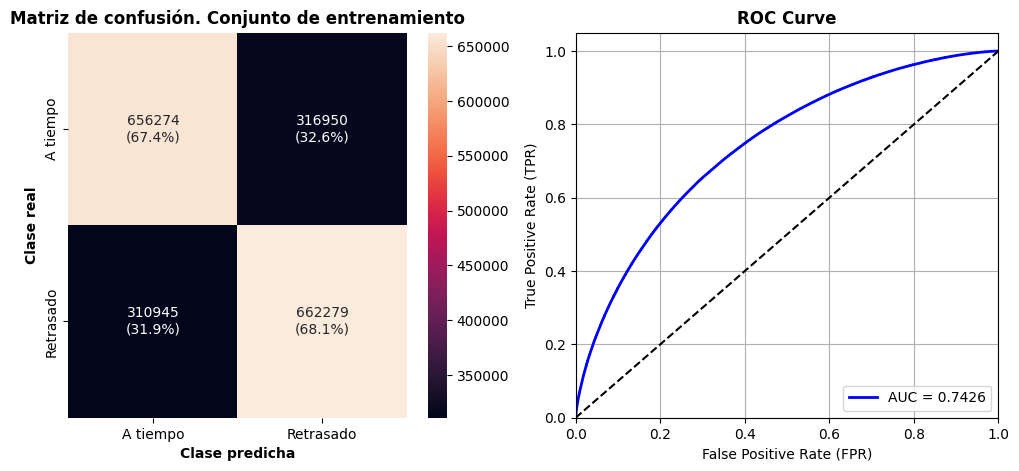

In [36]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_confusion_matrix(y_train, y_predicted_train, categories, 'Matriz de confusión. Conjunto de entrenamiento')
plt.subplot(1,2,2)
plot_roc_curve(y_train, y_predicted_proba_train)
plt.show()

In [37]:
y_predicted = best_model.predict(X_test)
y_predicted_proba = best_model.predict_proba(X_test)[:, 1]

testing_reporte = classification_report(y_test, y_predicted, output_dict=True)
testing_reporte_df = pd.DataFrame(testing_reporte).T

In [49]:
testing_reporte_df

,precision,recall,f1-score,support
0,0.886696,0.657794,0.755283,1.673918e+06
1,0.324329,0.661504,0.435256,4.156620e+05
accuracy,0.658532,0.658532,0.658532,6.585319e-01
macro avg,0.605513,0.659649,0.595269,2.089580e+06
weighted avg,0.774829,0.658532,0.691623,2.089580e+06


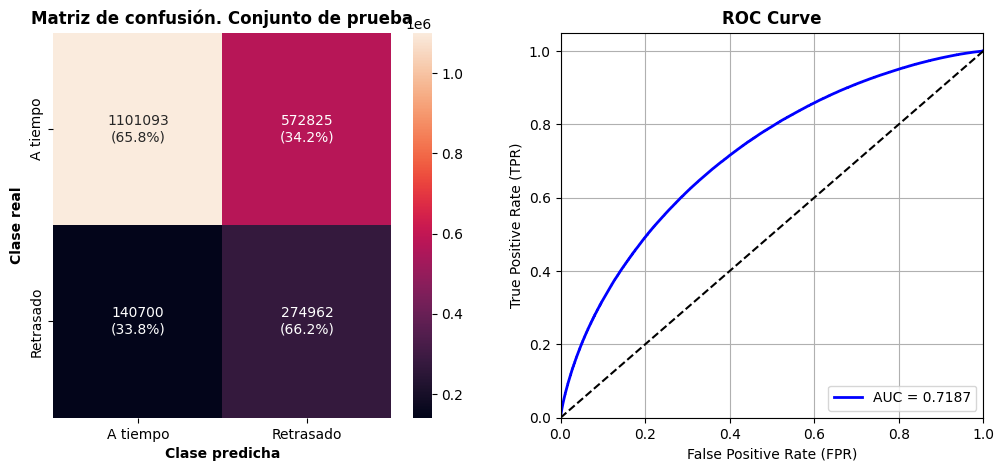

In [50]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_confusion_matrix(y_test, y_predicted, categories, 'Matriz de confusión. Conjunto de prueba')
plt.subplot(1,2,2)
plot_roc_curve(y_test, y_predicted_proba)
plt.show()

In [ ]:
from sklearn.dummy import DummyClassifier

In [ ]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(X_train, y_train)

y_pred_train_dummy = dummy.predict(X_train)
y_pred_dummy = dummy.predict(X_test)
y_pred_probs_dummy = dummy.predict_proba(X_test)[:, 1]

In [ ]:
testing_reporte = classification_report(y_test, y_pred_dummy, output_dict=True)
testing_reporte_df_dummy = pd.DataFrame(testing_reporte).T

In [ ]:
testing_reporte_df_dummy

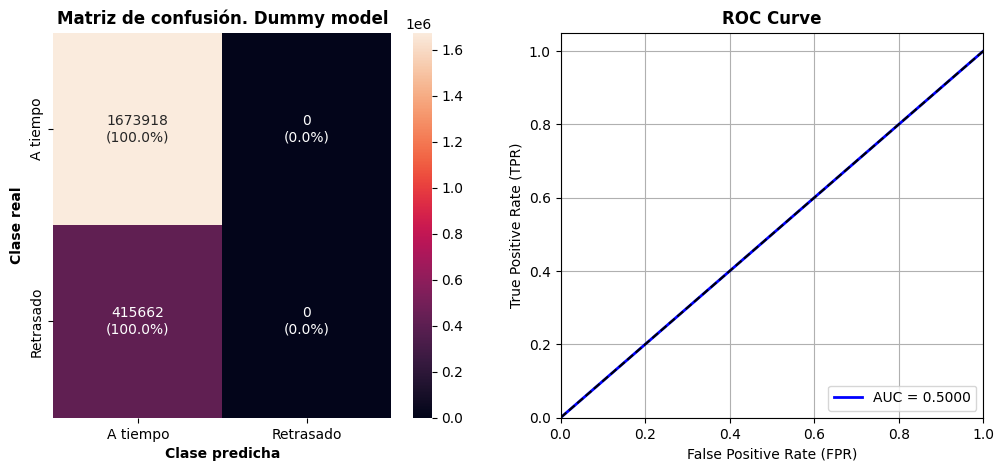

In [44]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_confusion_matrix(y_test, y_pred_dummy, categories, 'Matriz de confusión. Dummy model')
plt.subplot(1,2,2)
plot_roc_curve(y_test, y_pred_probs_dummy)
plt.show()

In [45]:
class CustomPrediction:
    def __init__(self, pipeline):
        self.pipeline = pipeline

        self.gen_date = pipeline.named_steps["gen-date"]
        self.gen_dist = pipeline.named_steps["gen-dist"]
        self.prep = pipeline.named_steps["preprocessing"]
        self.model = pipeline.named_steps["model"]

        self.feature_names = self.prep.get_feature_names_out()

        self.explainer = shap.TreeExplainer(self.model)

    def _transform_until_preprocess(self, X):
        X = self.gen_date.transform(X)
        X = self.gen_dist.transform(X)
        return X

    def predict(self, X):
        probs = self.pipeline.predict_proba(X)
        idx  = np.argmax(probs, axis=1)
        labels = ['A tiempo', 'Retrasado']
        max_prob = np.round(np.max(probs, axis=1) * 100, 2)

        return [{"Predicción": labels[i], "Probabilidad": f"{p} %"} for i, p in zip(idx, max_prob)]

    def explain(self, X):

        X_feat = self._transform_until_preprocess(X)
        X_trans = self.prep.transform(X_feat)

        shap_values = self.explainer.shap_values(X_trans)

        shap_df = pd.DataFrame(
                              shap_values,
                              columns=self.feature_names
                          )

        feature_groups = {
                        "hora de vuelo": [c for c in shap_df.columns if "hora_" in c],
                        "mes de vuelo": [c for c in shap_df.columns if "mes_" in c],
                        "día de la semana": [c for c in shap_df.columns if "dia_semana_" in c],
                    }

        grouped_shap = shap_df.copy()

        for group, cols in feature_groups.items():
            grouped_shap[group] = shap_df[cols].sum(axis=1)
            grouped_shap.drop(columns=cols, inplace=True)

        grouped_shap = grouped_shap.abs().T
        grouped_shap.columns = ["Importancia"]
        grouped_shap = grouped_shap.sort_values(by='Importancia', ascending=False)

        return grouped_shap

In [46]:
custom_model = CustomPrediction(best_model)

In [47]:
importancia_features = custom_model.explain(X_test.sample(1))
print(importancia_features)

                                 Importancia
categorical__aerolinea              0.384519
categorical__aeropuerto_origen      0.194084
hora de vuelo                       0.144973
día de la semana                    0.075379
numerical__distancia_millas         0.069361
bool__fin_de_semana                 0.017164
mes de vuelo                        0.015403
categorical__aeropuerto_destino     0.010069


In [48]:
predicciones = custom_model.predict(X_test.sample(1))
print(predicciones)

[{'Predicción': 'Retrasado', 'Probabilidad': '53.560001373291016 %'}]
